# 【介護DX提案】訪問介護シフト改善シミュレーション

## 1. 分析の目的

訪問介護シフト最適化に関する
PoC（概念実証）として、
Pythonを用いたシミュレーション分析を実施した。

訪問介護では、
移動時間増加による生産性低下が課題となる一方で、
単純な最短距離のみでは
現実的なシフトを作成できないケースも多い。

そのため本分析では、

- 移動効率
- 稼働上限
- 時間重複
- スタッフ負担

を段階的に考慮しながら、
現実的なシフト作成が可能かを検証する。

## 2. 訪問介護シフト作成の課題

訪問介護では、
利用者宅間の移動時間を短縮することで、
業務効率や売上向上につながる。

しかし、実際のシフト作成は、
単純に「近い訪問先を順番に回る」だけでは成立しない。

主な理由として、以下の制約が存在する。

- 利用者ごとの訪問時間指定
- サービスコードごとの提供条件
- スタッフごとの勤務可能時間
- 同一時間帯の訪問重複回避
- スタッフごとのスキル差
- 曜日や時間帯による訪問集中
- 急なキャンセルや欠勤対応

そのため、
「距離が近いスタッフ」が常に最適とは限らず、
移動時間・時間制約・スタッフ負担を
同時に考慮する必要がある。

さらに、訪問介護事業所では、
ケアマネジャーとの連携も重要となる。

ケアマネジャーからの依頼が
新規利用につながるケースも多く、
事業所側は地域内の幅広い依頼へ対応している。

この結果、

- 地理的に離れた利用者の受け入れ
- 一部非効率な訪問への対応

も発生する。

以上より、訪問介護シフトでは、
単純な最短距離だけではなく、
現場制約・地域連携・事業運営を含めた
総合的な判断が求められる。

## 3. 前提条件

以下の条件を設定する。

| 項目 | 条件 |
|---|---|
| 対象エリア | 名古屋市内を想定 |
| 利用者数 | 100名 |
| 訪問回数 | 1人あたり1日3回 |
| 1回あたり訪問時間 | 60分 |
| 総訪問件数 | 300件/日 |
| スタッフ数 | 60名 |
| 対応可能時間帯 | 7:00〜21:00 |
| スタッフの拘束時間 | 9時間 |
| スタッフの実稼働上限 | 8時間 |
| 休憩時間 | 1時間 |
| 基準移動時間 | 1件あたり30分と仮定 |
| サービスコード | 身体介護系サービスを想定 |
| 同一利用者への訪問間隔 | 2時間以上 |

In [ ]:
# =========================================
# ライブラリの読み込み
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

pd.set_option("display.max_columns", None)

np.random.seed(42)

# =========================================
# 前提条件の設定
# =========================================

n_clients = 100
n_staff = 60
visits_per_client = 3

visit_duration = 60
travel_time_per_visit = 30

max_work_minutes = 8 * 60

service_start = "07:00"
service_end = "21:00"

total_visits = n_clients * visits_per_client
total_visit_minutes = total_visits * visit_duration
total_travel_minutes = total_visits * travel_time_per_visit
total_required_minutes = total_visit_minutes + total_travel_minutes

total_staff_capacity_minutes = n_staff * max_work_minutes
surplus_minutes = total_staff_capacity_minutes - total_required_minutes

## 4. Pythonを用いた理由

本分析では、
複数条件を同時に扱う必要があったため、
Pythonを用いてシミュレーションおよび評価を行った。

特に訪問介護シフトでは、

- 距離
- 時間制約
- 稼働上限
- 負担平準化

など、複数条件を同時に扱う。

Excelのみで管理する場合と比較して、
条件変更やシミュレーションを柔軟に実施できる点に
Python活用の有効性がある。

## 5. 分析の前提と計算ロジック

本分析では、
利用者100名に対して1日3回訪問すると仮定し、
総訪問件数を300件とした。

訪問時間は1件あたり60分と設定し、
訪問サービス時間は合計300時間である。

さらに、1件あたり平均30分の移動時間を想定すると、
移動時間は合計150時間となる。

訪問時間と移動時間を合わせた
総必要時間は450時間である。

スタッフ60名が
1人あたり最大8時間まで稼働可能とした場合、
全体の最大稼働時間は480時間となる。

理論上は運用可能であり、
30時間の余剰を確保できる計算である。

また、総必要時間450時間を
スタッフ1名あたり8時間で換算すると、
必要最低人数は56.25名となる。

本分析では、
一定の余剰を持たせるため、
60名体制を採用した。

以上の前提をもとに、
シフト割り当て改善による効率化を検証する。

In [ ]:
# =========================================
# 前提条件の確認
# =========================================

summary = pd.DataFrame({
    "項目": [
        "利用者数",
        "スタッフ数",
        "総訪問件数",
        "総訪問時間",
        "総移動時間",
        "総必要時間",
        "スタッフ全体の最大稼働時間",
        "余剰時間"
    ],
    "値": [
        f"{n_clients} 名",
        f"{n_staff} 名",
        f"{total_visits} 件",
        f"{total_visit_minutes / 60:.1f} 時間",
        f"{total_travel_minutes / 60:.1f} 時間",
        f"{total_required_minutes / 60:.1f} 時間",
        f"{total_staff_capacity_minutes / 60:.1f} 時間",
        f"{surplus_minutes / 60:.1f} 時間"
    ]
})

display(summary)

if surplus_minutes >= 0:
    print("理論上は運用可能です。")
    print(f"余剰時間は {surplus_minutes / 60:.1f} 時間です。")
else:
    print("現在の条件では運用が難しい可能性があります。")
    print(f"不足時間は {abs(surplus_minutes) / 60:.1f} 時間です。")

,項目,値
0,利用者数,100 名
1,スタッフ数,60 名
2,総訪問件数,300 件
3,総訪問時間,300.0 時間
4,総移動時間,150.0 時間
5,総必要時間,450.0 時間
6,スタッフ全体の最大稼働時間,480.0 時間
7,余剰時間,30.0 時間


理論上は運用可能です。
余剰時間は 30.0 時間です。


## 6. 利用者・スタッフ位置データの作成

本分析では、
名古屋市内の訪問介護事業所を想定し、
利用者およびスタッフの位置情報を疑似的に作成した。

実際の住所データは使用せず、
名古屋駅周辺を中心として、
緯度・経度をおおよそ±0.08度の範囲に設定している。

緯度1度は約111kmであるため、
0.08度は約8〜9km程度に相当する。

利用者宅とスタッフ拠点は、
この範囲内へランダムに配置した。

実際の訪問介護では、
利用者配置や地域連携状況によって、
移動距離にばらつきが生じる。

特に、地域横断的な長距離訪問が発生するケースもあり、
必ずしも近距離訪問だけで運用できるとは限らない。

本分析でも、
近距離訪問と長距離訪問が混在する状況を想定し、
移動時間に一定のばらつきを持たせている。

In [ ]:
# =========================================
# 利用者・スタッフ位置データの作成
# =========================================

# 名古屋駅付近の緯度・経度を中心点として設定
nagoya_center_lat = 35.1709
nagoya_center_lon = 136.8815

# 名古屋市内を想定し、中心点からおおよそ±0.08度の範囲に配置
# ※実在の住所ではなく、シミュレーション用の架空データ
lat_range = 0.08
lon_range = 0.08

# 利用者データ
clients = pd.DataFrame({
    "client_id": range(1, n_clients + 1),
    "latitude": np.random.uniform(
        nagoya_center_lat - lat_range,
        nagoya_center_lat + lat_range,
        n_clients
    ),
    "longitude": np.random.uniform(
        nagoya_center_lon - lon_range,
        nagoya_center_lon + lon_range,
        n_clients
    )
})

# スタッフデータ
staff = pd.DataFrame({
    "staff_id": range(1, n_staff + 1),
    "latitude": np.random.uniform(
        nagoya_center_lat - lat_range,
        nagoya_center_lat + lat_range,
        n_staff
    ),
    "longitude": np.random.uniform(
        nagoya_center_lon - lon_range,
        nagoya_center_lon + lon_range,
        n_staff
    )
})

display(clients.head())
display(staff.head())

,client_id,latitude,longitude
0,1,35.150826,136.806529
1,2,35.243014,136.903326
2,3,35.208019,136.851797
3,4,35.186685,136.882871
4,5,35.115863,136.946711


,staff_id,latitude,longitude
0,1,35.193625,136.899901
1,2,35.104362,136.959909
2,3,35.116761,136.823913
3,4,35.234669,136.884433
4,5,35.187929,136.941880


## 7. 利用者・スタッフ位置の可視化

作成した利用者とスタッフの位置情報を散布図で見ていく。

この図により、利用者宅とスタッフ拠点が名古屋市内を想定した範囲に分布していることを確認する。

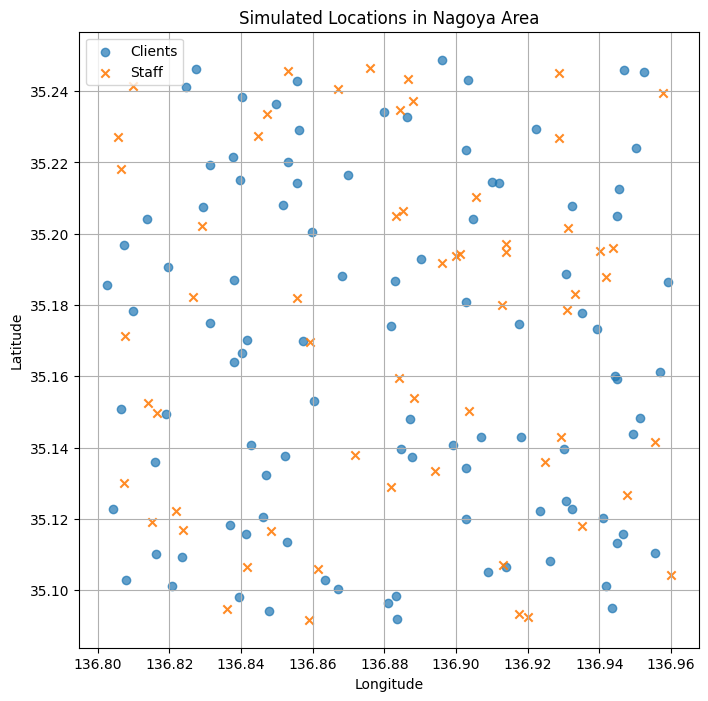

In [ ]:
# =========================================
# 利用者・スタッフ位置の可視化
# =========================================

plt.figure(figsize=(8, 8))

plt.scatter(
    clients["longitude"],
    clients["latitude"],
    label="Clients",
    alpha=0.7
)

plt.scatter(
    staff["longitude"],
    staff["latitude"],
    label="Staff",
    marker="x",
    alpha=0.9
)

plt.title("Simulated Locations in Nagoya Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()

## 8. 訪問タスクデータの作成

次に、利用者100名に対して、
1人あたり1日3回の訪問タスクを作成する。

対応可能時間帯は7:00〜21:00とし、
15分単位で訪問開始時刻を設定した。

訪問時間は1件あたり60分とし、
各タスクに開始時刻と終了時刻を持たせている。

また、同一利用者への複数回訪問については、
前後の訪問間隔が2時間以上空くよう設定した。

これにより、
単純なランダムデータではなく、
訪問介護の実務制約を反映した
訪問タスクデータを作成している。

In [ ]:
# =========================================
# 15分刻みの時間枠を作成
# =========================================

service_start_dt = datetime.strptime("07:00", "%H:%M")
service_end_dt = datetime.strptime("21:00", "%H:%M")

time_slots = []
current_time = service_start_dt

while current_time + timedelta(minutes=visit_duration) <= service_end_dt:
    end_time = current_time + timedelta(minutes=visit_duration)

    time_slots.append({
        "start_time": current_time.strftime("%H:%M"),
        "end_time": end_time.strftime("%H:%M"),
        "start_minutes": current_time.hour * 60 + current_time.minute,
        "end_minutes": end_time.hour * 60 + end_time.minute
    })

    current_time += timedelta(minutes=15)

time_slots_df = pd.DataFrame(time_slots)

display(time_slots_df.head())
print("利用可能な開始時刻数:", len(time_slots_df))

,start_time,end_time,start_minutes,end_minutes
0,07:00,08:00,420,480
1,07:15,08:15,435,495
2,07:30,08:30,450,510
3,07:45,08:45,465,525
4,08:00,09:00,480,540


利用可能な開始時刻数: 53


In [ ]:
# =========================================
# 訪問タスク作成
#    ※身体2を想定し、同一利用者の訪問間隔は2時間以上空ける
# =========================================

visit_tasks = []

# 同一利用者の訪問間隔（分）
min_interval_between_visits = 120

for _, client in clients.iterrows():

    selected_slots = []
    attempt_count = 0
    max_attempts = 1000

    while len(selected_slots) < visits_per_client and attempt_count < max_attempts:
        attempt_count += 1

        slot = time_slots_df.sample(
            n=1,
            random_state=int(client["client_id"]) * 1000 + attempt_count
        ).iloc[0]

        is_valid = True

        for selected_slot in selected_slots:
            # 時間帯が重なっていないか確認
            no_overlap = (
                slot["end_minutes"] <= selected_slot["start_minutes"] or
                slot["start_minutes"] >= selected_slot["end_minutes"]
            )

            # 訪問間隔を確認
            if slot["start_minutes"] >= selected_slot["end_minutes"]:
                gap = slot["start_minutes"] - selected_slot["end_minutes"]
            elif selected_slot["start_minutes"] >= slot["end_minutes"]:
                gap = selected_slot["start_minutes"] - slot["end_minutes"]
            else:
                gap = 0

            if (not no_overlap) or gap < min_interval_between_visits:
                is_valid = False
                break

        if is_valid:
            selected_slots.append(slot)

    if len(selected_slots) < visits_per_client:
        print(f"client_id {client['client_id']} の訪問時間を3件作成できませんでした。")

    for slot in selected_slots:
        visit_tasks.append({
            "task_id": f"C{int(client['client_id']):03d}_{slot['start_time']}",
            "client_id": int(client["client_id"]),
            "service_code": "身体2",
            "start_time": slot["start_time"],
            "end_time": slot["end_time"],
            "start_minutes": int(slot["start_minutes"]),
            "end_minutes": int(slot["end_minutes"]),
            "visit_duration_min": visit_duration,
            "latitude": client["latitude"],
            "longitude": client["longitude"]
        })

tasks = pd.DataFrame(visit_tasks)
tasks = tasks.sort_values(["start_minutes", "client_id"]).reset_index(drop=True)

display(tasks.head(10))
print("総訪問タスク数:", len(tasks))

,task_id,client_id,service_code,start_time,end_time,start_minutes,end_minutes,visit_duration_min,latitude,longitude
0,C010_07:00,10,身体2,07:00,08:00,420,480,60,35.204192,136.813817
1,C019_07:00,19,身体2,07:00,08:00,420,480,60,35.160011,136.944309
2,C022_07:00,22,身体2,07:00,08:00,420,480,60,35.113219,136.944875
3,C039_07:00,39,身体2,07:00,08:00,420,480,60,35.200377,136.859681
4,C061_07:00,61,身体2,07:00,08:00,420,480,60,35.153088,136.860345
5,C080_07:00,80,身体2,07:00,08:00,420,480,60,35.109439,136.823503
6,C082_07:00,82,身体2,07:00,08:00,420,480,60,35.190628,136.819656
7,C087_07:00,87,身体2,07:00,08:00,420,480,60,35.207637,136.932256
8,C088_07:00,88,身体2,07:00,08:00,420,480,60,35.192909,136.890332
9,C099_07:00,99,身体2,07:00,08:00,420,480,60,35.094967,136.943434


総訪問タスク数: 300


## 9. 訪問タスク作成結果の確認

作成した訪問タスクについて、想定通り300件作成されているかを確認する。

同一利用者に対する訪問間隔が2時間以上空いているかを確認し、
身体介護2を想定した制約が守られているかを検証する。

In [ ]:
# =========================================
# 訪問タスク作成結果の確認
# =========================================

print("想定される総訪問件数:", n_clients * visits_per_client)
print("実際の訪問タスク数:", len(tasks))

# 同一利用者の訪問間隔チェック
violations = []

for client_id, group in tasks.groupby("client_id"):
    group = group.sort_values("start_minutes")

    for i in range(len(group) - 1):
        current_end = group.iloc[i]["end_minutes"]
        next_start = group.iloc[i + 1]["start_minutes"]
        gap = next_start - current_end

        if gap < min_interval_between_visits:
            violations.append({
                "client_id": client_id,
                "current_end": current_end,
                "next_start": next_start,
                "gap": gap
            })

violations_df = pd.DataFrame(violations)

print("訪問間隔違反数:", len(violations_df))
display(violations_df.head())

想定される総訪問件数: 300
実際の訪問タスク数: 300
訪問間隔違反数: 0


""


## 10. 現状シフトの作成

まず、比較用の基準として現状シフトを作成する。

ここでは、
訪問タスクをスタッフへランダムに割り当てることで、
最適化を行わない状態を再現した。

この現状シフトを基準とし、
後続の改善施策による効果を比較していく。

In [ ]:
# =========================================
# 現状シフト作成（ランダム割当）
# =========================================

current_shift = tasks.copy()

current_shift["staff_id"] = np.random.choice(
    staff["staff_id"],
    size=len(tasks)
)

# 仮の移動時間（まずは固定）
current_shift["travel_time_min"] = 30

## 11. 現状シフトの評価

作成した現状シフトについて、
以下の観点から評価を行う。

- スタッフごとの担当件数
- 訪問時間
- 移動時間
- 総稼働時間
- 稼働上限（8時間）超過の有無

これにより、
シフト内に存在する
非効率な移動や負担偏りを確認する。

In [ ]:
# =========================================
# スタッフ別の稼働状況
# =========================================

current_workload = current_shift.groupby("staff_id").agg(
    task_count=("task_id", "count"),
    total_visit=("visit_duration_min", "sum"),
    total_travel=("travel_time_min", "sum")
).reset_index()

current_workload["total_work"] = (
    current_workload["total_visit"] + current_workload["total_travel"]
)

display(current_workload.head())

,staff_id,task_count,total_visit,total_travel,total_work
0,1,6,360,180,540
1,2,3,180,90,270
2,3,4,240,120,360
3,4,3,180,90,270
4,5,8,480,240,720


In [ ]:
# =========================================
# 稼働上限チェック
# =========================================

current_workload["over_capacity"] = (
    current_workload["total_work"] > max_work_minutes
)

over_count = current_workload["over_capacity"].sum()

print("稼働上限超過スタッフ数:", over_count, "名")

稼働上限超過スタッフ数: 21 名


In [ ]:
# =========================================
# サマリー
# =========================================

current_summary = pd.DataFrame({
    "指標": [
        "平均担当件数",
        "最大担当件数",
        "平均稼働時間（時間）",
        "最大稼働時間（時間）"
    ],
    "値": [
        current_workload["task_count"].mean(),
        current_workload["task_count"].max(),
        current_workload["total_work"].mean() / 60,
        current_workload["total_work"].max() / 60
    ]
})

display(current_summary)

,指標,値
0,平均担当件数,5.0
1,最大担当件数,11.0
2,平均稼働時間（時間）,7.5
3,最大稼働時間（時間）,16.5


## 12. 現状シフトの問題点

現状シフトの評価結果から、
以下の課題が確認された。

- スタッフごとの担当件数にばらつきがある
- 移動時間を考慮していない
- 一部スタッフで稼働上限（8時間）を超過している

これらの結果から、
ランダム割り当てだけでは、
訪問介護シフトとして現実的な運用は難しいと分かる。

次章以降では、
上記の課題に対して改善手法を段階的に適用する。

## 13. 改善①：担当件数の均等化

現状シフトでは、
訪問タスクをランダムに割り当てたため、
スタッフごとの担当件数や稼働時間にばらつきが生じていた。

そこで、最初の改善として、
300件の訪問タスクを
60名のスタッフへ均等に割り当てる。

本条件では、
300件 ÷ 60名 = 5件となるため、
各スタッフが原則5件ずつ担当する形を想定した。

この改善では、
スタッフ間の担当件数偏りが
どの程度抑制されるかを確認する。

In [ ]:
# =========================================
#  改善①：担当件数の均等化
# =========================================

equal_shift = tasks.copy()

# 300件 / 60名 = 5件ずつ割り当て
staff_assignment = np.repeat(
    staff["staff_id"].values,
    len(equal_shift) // n_staff
)

# 件数が割り切れない場合に備えて不足分を追加
remaining_tasks = len(equal_shift) - len(staff_assignment)

if remaining_tasks > 0:
    extra_staff = staff["staff_id"].sample(
        n=remaining_tasks,
        replace=False,
        random_state=42
    ).values

    staff_assignment = np.concatenate([staff_assignment, extra_staff])

equal_shift["staff_id"] = staff_assignment

# まずは現状シフトと同じく、1件あたり30分の移動時間で評価する
equal_shift["travel_time_min"] = travel_time_per_visit

display(equal_shift.head(10))
print("均等割りシフトの訪問件数:", len(equal_shift))

,task_id,client_id,service_code,start_time,end_time,start_minutes,end_minutes,visit_duration_min,latitude,longitude,staff_id,travel_time_min
0,C010_07:00,10,身体2,07:00,08:00,420,480,60,35.204192,136.813817,1,30
1,C019_07:00,19,身体2,07:00,08:00,420,480,60,35.160011,136.944309,1,30
2,C022_07:00,22,身体2,07:00,08:00,420,480,60,35.113219,136.944875,1,30
3,C039_07:00,39,身体2,07:00,08:00,420,480,60,35.200377,136.859681,1,30
4,C061_07:00,61,身体2,07:00,08:00,420,480,60,35.153088,136.860345,1,30
5,C080_07:00,80,身体2,07:00,08:00,420,480,60,35.109439,136.823503,2,30
6,C082_07:00,82,身体2,07:00,08:00,420,480,60,35.190628,136.819656,2,30
7,C087_07:00,87,身体2,07:00,08:00,420,480,60,35.207637,136.932256,2,30
8,C088_07:00,88,身体2,07:00,08:00,420,480,60,35.192909,136.890332,2,30
9,C099_07:00,99,身体2,07:00,08:00,420,480,60,35.094967,136.943434,2,30


均等割りシフトの訪問件数: 300


In [ ]:
# =========================================
# 改善①の評価
# =========================================

equal_workload = (
    equal_shift
    .groupby("staff_id")
    .agg(
        task_count=("task_id", "count"),
        total_visit=("visit_duration_min", "sum"),
        total_travel=("travel_time_min", "sum")
    )
    .reset_index()
)

equal_workload["total_work"] = (
    equal_workload["total_visit"] + equal_workload["total_travel"]
)

equal_workload["over_capacity"] = (
    equal_workload["total_work"] > max_work_minutes
)

display(equal_workload.head())

print("稼働上限超過スタッフ数:", equal_workload["over_capacity"].sum(), "名")
print("平均稼働時間:", equal_workload["total_work"].mean() / 60, "時間")
print("最大稼働時間:", equal_workload["total_work"].max() / 60, "時間")
print("最小稼働時間:", equal_workload["total_work"].min() / 60, "時間")

,staff_id,task_count,total_visit,total_travel,total_work,over_capacity
0,1,5,300,150,450,False
1,2,5,300,150,450,False
2,3,5,300,150,450,False
3,4,5,300,150,450,False
4,5,5,300,150,450,False


稼働上限超過スタッフ数: 0 名
平均稼働時間: 7.5 時間
最大稼働時間: 7.5 時間
最小稼働時間: 7.5 時間


In [ ]:
# =========================================
#  現状シフトと均等割りの比較
# =========================================

comparison_equal = pd.DataFrame({
    "指標": [
        "稼働上限超過スタッフ数",
        "平均担当件数",
        "最大担当件数",
        "最小担当件数",
        "平均稼働時間（時間）",
        "最大稼働時間（時間）",
        "最小稼働時間（時間）",
        "稼働時間のばらつき"
    ],
    "現状シフト": [
        current_workload["over_capacity"].sum(),
        current_workload["task_count"].mean(),
        current_workload["task_count"].max(),
        current_workload["task_count"].min(),
        current_workload["total_work"].mean() / 60,
        current_workload["total_work"].max() / 60,
        current_workload["total_work"].min() / 60,
        current_workload["total_work"].std() / 60
    ],
    "均等割り": [
        equal_workload["over_capacity"].sum(),
        equal_workload["task_count"].mean(),
        equal_workload["task_count"].max(),
        equal_workload["task_count"].min(),
        equal_workload["total_work"].mean() / 60,
        equal_workload["total_work"].max() / 60,
        equal_workload["total_work"].min() / 60,
        equal_workload["total_work"].std() / 60
    ]
})

display(comparison_equal)

,指標,現状シフト,均等割り
0,稼働上限超過スタッフ数,21.000000,0.0
1,平均担当件数,5.000000,5.0
2,最大担当件数,11.000000,5.0
3,最小担当件数,1.000000,5.0
4,平均稼働時間（時間）,7.500000,7.5
5,最大稼働時間（時間）,16.500000,7.5
6,最小稼働時間（時間）,1.500000,7.5
7,稼働時間のばらつき,3.359782,0.0


## 14. 改善①の結果と課題

担当件数を均等に割り当てたことで、
スタッフごとの件数ばらつきは抑制された。

現状シフトと比較すると、
負担偏りも一定程度改善している。

この方法では、
利用者宅とスタッフの位置関係を考慮していない。

そのため、
担当件数が均等であっても、
移動距離や移動時間が最適化されるとは限らない。

担当件数の均等化は、
負担平準化には有効である一方、
移動効率改善には限界がある。

次章では、
利用者とスタッフの位置情報を用い、
距離を考慮した割り当てを検討する。

## 15. 改善②：距離ベース割り当て

均等割りによって、
スタッフごとの担当件数は平準化された。

利用者宅とスタッフの位置関係は考慮していないため、
移動時間削減という観点では課題が残る。

そこで本章では、
利用者とスタッフの位置情報をもとに、
各訪問タスクを最も近いスタッフへ割り当てる。

距離を考慮した割り当てによって、
移動時間や稼働状況が
どのように変化するかを確認する。

なお、本分析で使用する距離は、
緯度・経度を用いた簡易距離であり、
実際の道路距離や交通状況は反映していない。

実運用では、

- 一方通行
- 渋滞
- 信号
- 駐車可否
- 建物構造

といった条件も移動時間へ影響する。

そのため、実導入時には、
Google Maps API等を用いた
実道路ベースの移動時間計算へ
拡張可能である。

In [ ]:
# =========================================
#  距離計算関数
# =========================================

def calculate_distance(lat1, lon1, lat2, lon2):
    """
    緯度・経度の差から簡易的な距離を計算する関数。
    今回はシミュレーションのため、厳密な道路距離ではなく簡易距離を使う。
    """
    return np.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)


def distance_to_travel_time(distance):
    """
    簡易距離を移動時間に変換する関数。
    最低15分、最大45分の範囲に収める。
    """
    travel_time = distance * 300
    travel_time = max(15, min(travel_time, 45))
    return travel_time

In [ ]:
# =========================================
# 距離ベース割り当て
# =========================================

distance_shift = tasks.copy()

assigned_staff = []
assigned_distance = []
assigned_travel_time = []

for _, task in distance_shift.iterrows():

    candidate_staff = staff.copy()

    candidate_staff["distance"] = candidate_staff.apply(
        lambda row: calculate_distance(
            task["latitude"],
            task["longitude"],
            row["latitude"],
            row["longitude"]
        ),
        axis=1
    )

    nearest_staff = candidate_staff.sort_values("distance").iloc[0]

    assigned_staff.append(nearest_staff["staff_id"])
    assigned_distance.append(nearest_staff["distance"])
    assigned_travel_time.append(distance_to_travel_time(nearest_staff["distance"]))

distance_shift["staff_id"] = assigned_staff
distance_shift["distance"] = assigned_distance
distance_shift["travel_time_min"] = assigned_travel_time

display(distance_shift.head(10))

,task_id,client_id,service_code,start_time,end_time,start_minutes,end_minutes,visit_duration_min,latitude,longitude,staff_id,distance,travel_time_min
0,C010_07:00,10,身体2,07:00,08:00,420,480,60,35.204192,136.813817,58.0,0.015530,15
1,C019_07:00,19,身体2,07:00,08:00,420,480,60,35.160011,136.944309,54.0,0.021551,15
2,C022_07:00,22,身体2,07:00,08:00,420,480,60,35.113219,136.944875,55.0,0.010749,15
3,C039_07:00,39,身体2,07:00,08:00,420,480,60,35.200377,136.859681,22.0,0.018996,15
4,C061_07:00,61,身体2,07:00,08:00,420,480,60,35.153088,136.860345,34.0,0.016659,15
5,C080_07:00,80,身体2,07:00,08:00,420,480,60,35.109439,136.823503,3.0,0.007333,15
6,C082_07:00,82,身体2,07:00,08:00,420,480,60,35.190628,136.819656,59.0,0.010946,15
7,C087_07:00,87,身体2,07:00,08:00,420,480,60,35.207637,136.932256,12.0,0.006140,15
8,C088_07:00,88,身体2,07:00,08:00,420,480,60,35.192909,136.890332,30.0,0.005793,15
9,C099_07:00,99,身体2,07:00,08:00,420,480,60,35.094967,136.943434,2.0,0.018966,15


In [ ]:
# =========================================
# 改善②の評価
# =========================================

distance_workload = (
    distance_shift
    .groupby("staff_id")
    .agg(
        task_count=("task_id", "count"),
        total_visit=("visit_duration_min", "sum"),
        total_travel=("travel_time_min", "sum"),
        total_distance=("distance", "sum")
    )
    .reset_index()
)

distance_workload["total_work"] = (
    distance_workload["total_visit"] + distance_workload["total_travel"]
)

distance_workload["over_capacity"] = (
    distance_workload["total_work"] > max_work_minutes
)

display(distance_workload.sort_values("total_work", ascending=False).head(10))

print("稼働上限超過スタッフ数:", distance_workload["over_capacity"].sum(), "名")
print("総移動時間:", distance_workload["total_travel"].sum() / 60, "時間")
print("平均稼働時間:", distance_workload["total_work"].mean() / 60, "時間")
print("最大稼働時間:", distance_workload["total_work"].max() / 60, "時間")
print("最小稼働時間:", distance_workload["total_work"].min() / 60, "時間")

,staff_id,task_count,total_visit,total_travel,total_distance,total_work,over_capacity
6,10.0,18,1080,270,0.207075,1350,True
38,50.0,18,1080,270,0.261383,1350,True
42,55.0,18,1080,270,0.184407,1350,True
41,54.0,15,900,225,0.228601,1125,True
17,23.0,12,720,180,0.168419,900,True
13,18.0,12,720,180,0.100525,900,True
19,25.0,12,720,180,0.123462,900,True
27,34.0,12,720,180,0.164967,900,True
45,59.0,12,720,180,0.161339,900,True
22,29.0,9,540,135,0.066115,675,True


稼働上限超過スタッフ数: 12 名
総移動時間: 75.0 時間
平均稼働時間: 8.152173913043478 時間
最大稼働時間: 22.5 時間
最小稼働時間: 3.75 時間


In [ ]:
# =========================================
#  現状・均等割り・距離ベースの比較
# =========================================

comparison_distance = pd.DataFrame({
    "指標": [
        "稼働上限超過スタッフ数",
        "総移動時間（時間）",
        "平均稼働時間（時間）",
        "最大稼働時間（時間）",
        "最小稼働時間（時間）",
        "稼働時間のばらつき"
    ],
    "現状シフト": [
        current_workload["over_capacity"].sum(),
        current_workload["total_travel"].sum() / 60,
        current_workload["total_work"].mean() / 60,
        current_workload["total_work"].max() / 60,
        current_workload["total_work"].min() / 60,
        current_workload["total_work"].std() / 60
    ],
    "均等割り": [
        equal_workload["over_capacity"].sum(),
        equal_workload["total_travel"].sum() / 60,
        equal_workload["total_work"].mean() / 60,
        equal_workload["total_work"].max() / 60,
        equal_workload["total_work"].min() / 60,
        equal_workload["total_work"].std() / 60
    ],
    "距離ベース": [
        distance_workload["over_capacity"].sum(),
        distance_workload["total_travel"].sum() / 60,
        distance_workload["total_work"].mean() / 60,
        distance_workload["total_work"].max() / 60,
        distance_workload["total_work"].min() / 60,
        distance_workload["total_work"].std() / 60
    ]
})

display(comparison_distance)

,指標,現状シフト,均等割り,距離ベース
0,稼働上限超過スタッフ数,21.000000,0.0,12.000000
1,総移動時間（時間）,150.000000,150.0,75.000000
2,平均稼働時間（時間）,7.500000,7.5,8.152174
3,最大稼働時間（時間）,16.500000,7.5,22.500000
4,最小稼働時間（時間）,1.500000,7.5,3.750000
5,稼働時間のばらつき,3.359782,0.0,5.551146


## 16. 改善②の結果と課題

距離ベース割り当てでは、
利用者宅に近いスタッフを優先したことで、
移動時間削減効果が確認された。

距離のみを優先すると、
特定スタッフへ負担が集中しやすい。

また、
訪問介護では、
時間制約やサービス提供条件も存在するため、
単純な最短距離だけでは
現実的なシフトを作成できない。

この結果から、
距離だけでなく、

- 稼働上限
- 時間制約
- スタッフ負担

も考慮した設計が必要である。

## 17. 改善③：距離＋稼働上限＋時間重複なし

距離ベース割り当てでは、
移動時間削減が期待できる一方、
特定スタッフへ訪問タスクが集中しやすい。

また、単純に近いスタッフを選ぶだけでは、
同一時間帯の訪問が重複する可能性もある。

そこで本章では、
以下の条件を同時に考慮する。

- 利用者宅にできるだけ近いスタッフを選ぶ
- スタッフの総稼働時間が8時間を超えない
- 同一スタッフの訪問時間を重複させない

本改善では、
移動効率だけでなく、
実運用を想定したシフト作成が可能かを検証する。

In [ ]:
# =========================================
#  スタッフ時間重複チェック用の関数
# =========================================

def has_time_conflict(existing_schedules, new_start, new_end):
    """
    既存の訪問予定と、新しい訪問時間が重複しているかを確認する関数。
    重複があれば True、なければ False を返す。
    """
    for start, end in existing_schedules:
        if new_start < end and new_end > start:
            return True
    return False

In [ ]:
# =========================================
# 改善③：距離＋稼働上限＋時間重複なし
# =========================================

balanced_shift = tasks.copy()

# スタッフごとの稼働時間を管理
staff_work_minutes = {staff_id: 0 for staff_id in staff["staff_id"]}

# スタッフごとの訪問時間帯を管理
staff_schedules = {staff_id: [] for staff_id in staff["staff_id"]}

assigned_staff = []
assigned_distance = []
assigned_travel_time = []
unassigned_tasks = []

# 時間順にタスクを処理する
balanced_shift = balanced_shift.sort_values(["start_minutes", "client_id"]).reset_index(drop=True)

for _, task in balanced_shift.iterrows():

    candidate_staff = staff.copy()

    # 各スタッフと訪問先の距離を計算
    candidate_staff["distance"] = candidate_staff.apply(
        lambda row: calculate_distance(
            task["latitude"],
            task["longitude"],
            row["latitude"],
            row["longitude"]
        ),
        axis=1
    )

    # 近いスタッフから順に候補とする
    candidate_staff = candidate_staff.sort_values("distance")

    assigned = False

    for _, s in candidate_staff.iterrows():
        staff_id = s["staff_id"]
        distance = s["distance"]
        travel_time = distance_to_travel_time(distance)

        task_work_minutes = visit_duration + travel_time

        # 条件1：稼働上限を超えない
        capacity_ok = (
            staff_work_minutes[staff_id] + task_work_minutes <= max_work_minutes
        )

        # 条件2：同一スタッフの訪問時間が重ならない
        time_ok = not has_time_conflict(
            staff_schedules[staff_id],
            task["start_minutes"],
            task["end_minutes"]
        )

        if capacity_ok and time_ok:
            assigned_staff.append(staff_id)
            assigned_distance.append(distance)
            assigned_travel_time.append(travel_time)

            staff_work_minutes[staff_id] += task_work_minutes
            staff_schedules[staff_id].append(
                (task["start_minutes"], task["end_minutes"])
            )

            assigned = True
            break

    if not assigned:
        assigned_staff.append(None)
        assigned_distance.append(None)
        assigned_travel_time.append(None)
        unassigned_tasks.append(task["task_id"])

balanced_shift["staff_id"] = assigned_staff
balanced_shift["distance"] = assigned_distance
balanced_shift["travel_time_min"] = assigned_travel_time

display(balanced_shift.head(10))

print("未割当タスク数:", len(unassigned_tasks))

,task_id,client_id,service_code,start_time,end_time,start_minutes,end_minutes,visit_duration_min,latitude,longitude,staff_id,distance,travel_time_min
0,C010_07:00,10,身体2,07:00,08:00,420,480,60,35.204192,136.813817,58.0,0.015530,15.0
1,C019_07:00,19,身体2,07:00,08:00,420,480,60,35.160011,136.944309,54.0,0.021551,15.0
2,C022_07:00,22,身体2,07:00,08:00,420,480,60,35.113219,136.944875,55.0,0.010749,15.0
3,C039_07:00,39,身体2,07:00,08:00,420,480,60,35.200377,136.859681,22.0,0.018996,15.0
4,C061_07:00,61,身体2,07:00,08:00,420,480,60,35.153088,136.860345,34.0,0.016659,15.0
5,C080_07:00,80,身体2,07:00,08:00,420,480,60,35.109439,136.823503,3.0,0.007333,15.0
6,C082_07:00,82,身体2,07:00,08:00,420,480,60,35.190628,136.819656,59.0,0.010946,15.0
7,C087_07:00,87,身体2,07:00,08:00,420,480,60,35.207637,136.932256,12.0,0.006140,15.0
8,C088_07:00,88,身体2,07:00,08:00,420,480,60,35.192909,136.890332,30.0,0.005793,15.0
9,C099_07:00,99,身体2,07:00,08:00,420,480,60,35.094967,136.943434,2.0,0.018966,15.0


未割当タスク数: 0


In [ ]:
# =========================================
# 改善③の評価
# =========================================

balanced_workload = (
    balanced_shift
    .dropna(subset=["staff_id"])
    .groupby("staff_id")
    .agg(
        task_count=("task_id", "count"),
        total_visit=("visit_duration_min", "sum"),
        total_travel=("travel_time_min", "sum"),
        total_distance=("distance", "sum")
    )
    .reset_index()
)

balanced_workload["total_work"] = (
    balanced_workload["total_visit"] + balanced_workload["total_travel"]
)

balanced_workload["over_capacity"] = (
    balanced_workload["total_work"] > max_work_minutes
)

display(balanced_workload.sort_values("total_work", ascending=False).head(10))

print("稼働上限超過スタッフ数:", balanced_workload["over_capacity"].sum(), "名")
print("未割当タスク数:", len(unassigned_tasks))
print("総移動時間:", balanced_workload["total_travel"].sum() / 60, "時間")
print("平均稼働時間:", balanced_workload["total_work"].mean() / 60, "時間")
print("最大稼働時間:", balanced_workload["total_work"].max() / 60, "時間")
print("最小稼働時間:", balanced_workload["total_work"].min() / 60, "時間")

,staff_id,task_count,total_visit,total_travel,total_distance,total_work,over_capacity
10,11.0,6,360,100.394652,0.132591,460.394652,False
29,30.0,6,360,97.916358,0.122068,457.916358,False
3,4.0,6,360,90.000000,0.037663,450.000000,False
1,2.0,6,360,90.000000,0.099763,450.000000,False
8,9.0,6,360,90.000000,0.108545,450.000000,False
6,7.0,6,360,90.000000,0.073528,450.000000,False
9,10.0,6,360,90.000000,0.067285,450.000000,False
23,24.0,6,360,90.000000,0.085857,450.000000,False
16,17.0,6,360,90.000000,0.093382,450.000000,False
17,18.0,6,360,90.000000,0.054937,450.000000,False


稼働上限超過スタッフ数: 0 名
未割当タスク数: 0
総移動時間: 76.09340955757865 時間
平均稼働時間: 6.268223492626311 時間
最大稼働時間: 7.673244196953886 時間
最小稼働時間: 1.2609543283538325 時間


In [ ]:
# =========================================
# スタッフ時間重複の確認
# =========================================

staff_conflicts = []

for staff_id, group in balanced_shift.dropna(subset=["staff_id"]).groupby("staff_id"):
    group = group.sort_values("start_minutes")

    previous_end = None
    previous_task = None

    for _, row in group.iterrows():
        if previous_end is not None and row["start_minutes"] < previous_end:
            staff_conflicts.append({
                "staff_id": staff_id,
                "previous_task": previous_task,
                "current_task": row["task_id"],
                "current_start": row["start_time"],
                "current_end": row["end_time"]
            })

        previous_end = row["end_minutes"]
        previous_task = row["task_id"]

staff_conflicts_df = pd.DataFrame(staff_conflicts)

print("スタッフ時間重複件数:", len(staff_conflicts_df))
display(staff_conflicts_df.head())

スタッフ時間重複件数: 0


""


## 18. 改善③の結果と課題

距離・稼働上限・時間重複を同時に考慮した結果、
同一スタッフが同じ時間帯に
複数訪問を担当する状態は解消された。

また、総稼働時間を8時間以内に制御することで、
制約条件を満たすシフトへ近づいた。

制約条件を増やすほど、
割り当て可能な組み合わせは減少する。

その結果、
未割当タスクや、
スタッフ間の稼働偏りが残るケースも確認された。

未割当タスクが発生する主な要因は以下である。

- 同一時間帯への訪問集中
- スタッフ稼働上限
- 時間重複制約
- 距離条件

特に、
起床介助や就寝介助では、
特定時間帯へ需要が集中しやすい。

そのため、
単純にスタッフ人数を増やすだけでなく、

- 時間帯別の人員配置
- シフト分散
- 短時間スタッフ活用

といった運用面の工夫も重要となる。

## 19. 改善④：距離＋負担バランス

改善③では、
距離・稼働上限・時間重複を考慮することで、
実行可能なシフトへ近づいた。

しかし、
スタッフごとの担当件数や総稼働時間には、
まだ偏りが残っている。

そこで改善④では、

- 距離
- 稼働上限
- 時間重複

に加え、
スタッフごとの負担バランスも考慮する。

具体的には、
総稼働時間が少ないスタッフを優先的に割り当て、
特定スタッフへ負担が集中しにくい構成を目指す。

本改善では、
移動効率だけでなく、
スタッフ間の負担平準化も含めた
シフト最適化を検証する。

In [ ]:
# =========================================
# 改善④：距離＋負担バランス
# =========================================

balanced_shift_v2 = tasks.copy()

# スタッフごとの稼働時間を管理
staff_work_minutes_v2 = {staff_id: 0 for staff_id in staff["staff_id"]}

# スタッフごとの訪問時間帯を管理
staff_schedules_v2 = {staff_id: [] for staff_id in staff["staff_id"]}

assigned_staff = []
assigned_distance = []
assigned_travel_time = []
unassigned_tasks_v2 = []

# タスクは時間順に処理する
balanced_shift_v2 = balanced_shift_v2.sort_values(["start_minutes", "client_id"]).reset_index(drop=True)

for _, task in balanced_shift_v2.iterrows():

    candidate_staff = staff.copy()

    # 各スタッフと訪問先の距離を計算
    candidate_staff["distance"] = candidate_staff.apply(
        lambda row: calculate_distance(
            task["latitude"],
            task["longitude"],
            row["latitude"],
            row["longitude"]
        ),
        axis=1
    )

    # 現在の稼働時間を追加
    candidate_staff["current_work"] = candidate_staff["staff_id"].map(staff_work_minutes_v2)

    # 距離＋現在の負担をスコア化
    # current_work / max_work_minutes により、稼働率が高いスタッフほど選ばれにくくする
    candidate_staff["score"] = (
        candidate_staff["distance"]
        + (candidate_staff["current_work"] / max_work_minutes) * 0.5
    )

    # スコアが低いスタッフから候補とする
    candidate_staff = candidate_staff.sort_values("score")

    assigned = False

    for _, s in candidate_staff.iterrows():
        staff_id = s["staff_id"]
        distance = s["distance"]
        travel_time = distance_to_travel_time(distance)

        task_work_minutes = visit_duration + travel_time

        capacity_ok = (
            staff_work_minutes_v2[staff_id] + task_work_minutes <= max_work_minutes
        )

        time_ok = not has_time_conflict(
            staff_schedules_v2[staff_id],
            task["start_minutes"],
            task["end_minutes"]
        )

        if capacity_ok and time_ok:
            assigned_staff.append(staff_id)
            assigned_distance.append(distance)
            assigned_travel_time.append(travel_time)

            staff_work_minutes_v2[staff_id] += task_work_minutes
            staff_schedules_v2[staff_id].append(
                (task["start_minutes"], task["end_minutes"])
            )

            assigned = True
            break

    if not assigned:
        assigned_staff.append(None)
        assigned_distance.append(None)
        assigned_travel_time.append(None)
        unassigned_tasks_v2.append(task["task_id"])

balanced_shift_v2["staff_id"] = assigned_staff
balanced_shift_v2["distance"] = assigned_distance
balanced_shift_v2["travel_time_min"] = assigned_travel_time

display(balanced_shift_v2.head(10))

print("未割当タスク数:", len(unassigned_tasks_v2))

,task_id,client_id,service_code,start_time,end_time,start_minutes,end_minutes,visit_duration_min,latitude,longitude,staff_id,distance,travel_time_min
0,C010_07:00,10,身体2,07:00,08:00,420,480,60,35.204192,136.813817,58.0,0.015530,15.0
1,C019_07:00,19,身体2,07:00,08:00,420,480,60,35.160011,136.944309,54.0,0.021551,15.0
2,C022_07:00,22,身体2,07:00,08:00,420,480,60,35.113219,136.944875,55.0,0.010749,15.0
3,C039_07:00,39,身体2,07:00,08:00,420,480,60,35.200377,136.859681,22.0,0.018996,15.0
4,C061_07:00,61,身体2,07:00,08:00,420,480,60,35.153088,136.860345,34.0,0.016659,15.0
5,C080_07:00,80,身体2,07:00,08:00,420,480,60,35.109439,136.823503,3.0,0.007333,15.0
6,C082_07:00,82,身体2,07:00,08:00,420,480,60,35.190628,136.819656,59.0,0.010946,15.0
7,C087_07:00,87,身体2,07:00,08:00,420,480,60,35.207637,136.932256,12.0,0.006140,15.0
8,C088_07:00,88,身体2,07:00,08:00,420,480,60,35.192909,136.890332,30.0,0.005793,15.0
9,C099_07:00,99,身体2,07:00,08:00,420,480,60,35.094967,136.943434,2.0,0.018966,15.0


未割当タスク数: 0


In [ ]:
# =========================================
# 改善④の評価
# =========================================

balanced_workload_v2 = (
    balanced_shift_v2
    .dropna(subset=["staff_id"])
    .groupby("staff_id")
    .agg(
        task_count=("task_id", "count"),
        total_visit=("visit_duration_min", "sum"),
        total_travel=("travel_time_min", "sum"),
        total_distance=("distance", "sum")
    )
    .reset_index()
)

balanced_workload_v2["total_work"] = (
    balanced_workload_v2["total_visit"] + balanced_workload_v2["total_travel"]
)

balanced_workload_v2["over_capacity"] = (
    balanced_workload_v2["total_work"] > max_work_minutes
)

display(balanced_workload_v2.sort_values("total_work", ascending=False).head(10))

print("稼働上限超過スタッフ数:", balanced_workload_v2["over_capacity"].sum(), "名")
print("未割当タスク数:", len(unassigned_tasks_v2))
print("総移動時間:", balanced_workload_v2["total_travel"].sum() / 60, "時間")
print("平均稼働時間:", balanced_workload_v2["total_work"].mean() / 60, "時間")
print("最大稼働時間:", balanced_workload_v2["total_work"].max() / 60, "時間")
print("最小稼働時間:", balanced_workload_v2["total_work"].min() / 60, "時間")
print("稼働時間のばらつき:", balanced_workload_v2["total_work"].std() / 60)

,staff_id,task_count,total_visit,total_travel,total_distance,total_work,over_capacity
2,3.0,6,360,90.000000,0.081234,450.000000,False
9,10.0,6,360,90.000000,0.051664,450.000000,False
57,58.0,6,360,90.000000,0.106015,450.000000,False
34,35.0,6,360,90.000000,0.133698,450.000000,False
7,8.0,5,300,92.310877,0.259263,392.310877,False
18,19.0,5,300,89.406696,0.235331,389.406696,False
0,1.0,5,300,87.373039,0.267773,387.373039,False
4,5.0,5,300,85.874391,0.223217,385.874391,False
44,45.0,5,300,85.310402,0.157559,385.310402,False
26,27.0,5,300,83.869609,0.220676,383.869609,False


稼働上限超過スタッフ数: 0 名
未割当タスク数: 0
総移動時間: 77.21641875712693 時間
平均稼働時間: 6.286940312618782 時間
最大稼働時間: 7.5 時間
最小稼働時間: 5.0 時間
稼働時間のばらつき: 0.4425021876374145


In [ ]:
# =========================================
# 改善④の時間重複確認
# =========================================

staff_conflicts_v2 = []

for staff_id, group in balanced_shift_v2.dropna(subset=["staff_id"]).groupby("staff_id"):
    group = group.sort_values("start_minutes")

    previous_end = None
    previous_task = None

    for _, row in group.iterrows():
        if previous_end is not None and row["start_minutes"] < previous_end:
            staff_conflicts_v2.append({
                "staff_id": staff_id,
                "previous_task": previous_task,
                "current_task": row["task_id"],
                "current_start": row["start_time"],
                "current_end": row["end_time"]
            })

        previous_end = row["end_minutes"]
        previous_task = row["task_id"]

staff_conflicts_v2_df = pd.DataFrame(staff_conflicts_v2)

print("スタッフ時間重複件数:", len(staff_conflicts_v2_df))
display(staff_conflicts_v2_df.head())

スタッフ時間重複件数: 0


""


## 20. 改善④の結果

改善④では、
距離だけでなく、
スタッフごとの稼働状況も考慮した。

その結果、
稼働上限超過や時間重複を抑えながら、
負担平準化を意識したシフトとなった。

負担平準化を優先すると、
必ずしも最も近いスタッフを選択できず、
総移動時間が増加するケースも確認された。

訪問介護シフトでは、
移動効率と負担平準化の両立が重要である。

## 21. 手法比較

ここまで、
以下の5つのシフト手法を作成した。

- 現状シフト（ランダム割り当て）
- 改善①：担当件数の均等化
- 改善②：距離ベース割り当て
- 改善③：距離＋稼働上限＋時間重複回避
- 改善④：距離＋負担平準化

改善④では、
改善①〜③で追加した条件を維持しつつ、
スタッフ負担平準化も考慮している。

本章では、
各手法について、

- 移動時間
- 稼働時間
- 負担平準化
- 未割当タスク数

を比較し、
それぞれの特徴を整理する。

In [ ]:
# =========================================
# 手法比較表
# =========================================

comparison_all = pd.DataFrame({
    "指標": [
        "稼働上限超過スタッフ数",
        "未割当タスク数",
        "総移動時間（時間）",
        "平均稼働時間（時間）",
        "最大稼働時間（時間）",
        "最小稼働時間（時間）",
        "稼働時間のばらつき"
    ],

    "現状シフト": [
        current_workload["over_capacity"].sum(),
        0,
        current_workload["total_travel"].sum() / 60,
        current_workload["total_work"].mean() / 60,
        current_workload["total_work"].max() / 60,
        current_workload["total_work"].min() / 60,
        current_workload["total_work"].std() / 60
    ],

    "均等割り": [
        equal_workload["over_capacity"].sum(),
        0,
        equal_workload["total_travel"].sum() / 60,
        equal_workload["total_work"].mean() / 60,
        equal_workload["total_work"].max() / 60,
        equal_workload["total_work"].min() / 60,
        equal_workload["total_work"].std() / 60
    ],

    "距離ベース": [
        distance_workload["over_capacity"].sum(),
        0,
        distance_workload["total_travel"].sum() / 60,
        distance_workload["total_work"].mean() / 60,
        distance_workload["total_work"].max() / 60,
        distance_workload["total_work"].min() / 60,
        distance_workload["total_work"].std() / 60
    ],

    "改善③": [
        balanced_workload["over_capacity"].sum(),
        len(unassigned_tasks),
        balanced_workload["total_travel"].sum() / 60,
        balanced_workload["total_work"].mean() / 60,
        balanced_workload["total_work"].max() / 60,
        balanced_workload["total_work"].min() / 60,
        balanced_workload["total_work"].std() / 60
    ],

    "改善④": [
        balanced_workload_v2["over_capacity"].sum(),
        len(unassigned_tasks_v2),
        balanced_workload_v2["total_travel"].sum() / 60,
        balanced_workload_v2["total_work"].mean() / 60,
        balanced_workload_v2["total_work"].max() / 60,
        balanced_workload_v2["total_work"].min() / 60,
        balanced_workload_v2["total_work"].std() / 60
    ]
})

display(comparison_all)

,指標,現状シフト,均等割り,距離ベース,改善③,改善④
0,稼働上限超過スタッフ数,21.000000,0.0,12.000000,0.000000,0.000000
1,未割当タスク数,0.000000,0.0,0.000000,0.000000,0.000000
2,総移動時間（時間）,150.000000,150.0,75.000000,76.093410,77.216419
3,平均稼働時間（時間）,7.500000,7.5,8.152174,6.268223,6.286940
4,最大稼働時間（時間）,16.500000,7.5,22.500000,7.673244,7.500000
5,最小稼働時間（時間）,1.500000,7.5,3.750000,1.260954,5.000000
6,稼働時間のばらつき,3.359782,0.0,5.551146,1.689390,0.442502


##22. 比較結果の考察

手法ごとに制約条件を追加した結果、
移動効率と運用性の両立が段階的に改善した。

改善①では担当件数の偏りを抑制し、
改善②では移動時間削減効果が確認された。

さらに改善③で稼働上限と時間重複を考慮し、
改善④では負担平準化も組み込んだ。

その結果、
移動効率だけでなく、
実運用を見据えたシフト作成へ近づいた。

## 23. KPI評価

ここでは、
現状シフトと最終改善（改善④）を比較し、
シフト改善による効率化を定量的に確認する。

評価指標として、
以下のKPI（重要指標）を用いる。

- 総移動時間
- 総稼働時間
- 移動時間削減率
- 稼働効率
- 稼働上限超過スタッフ数
- 未割当タスク数

評価にあたっては、
単純な移動時間最小化ではなく、

- 稼働超過を発生させない
- 時間重複を回避する
- スタッフ負担を極端に偏らせない
- 実運用可能なシフトとする

ことを重視した。

そのため、
単一指標のみを最適化するのではなく、
複数制約を踏まえた
多面的なシフト最適化を行っている。

In [ ]:
# =========================================
# KPI評価
# =========================================

# -----------------------------
# 現状シフト
# -----------------------------
current_total_travel = current_workload["total_travel"].sum()

current_total_visit = current_workload["total_visit"].sum()

current_total_work = current_workload["total_work"].sum()

current_efficiency = (
    current_total_visit / current_total_work
)

# -----------------------------
# 改善④
# -----------------------------
final_total_travel = balanced_workload_v2["total_travel"].sum()

final_total_visit = balanced_workload_v2["total_visit"].sum()

final_total_work = balanced_workload_v2["total_work"].sum()

final_efficiency = (
    final_total_visit / final_total_work
)

# -----------------------------
# 改善率
# -----------------------------
travel_reduction_rate = (
    (current_total_travel - final_total_travel)
    / current_total_travel
) * 100

efficiency_improvement_rate = (
    (final_efficiency - current_efficiency)
    / current_efficiency
) * 100

# -----------------------------
# KPI表
# -----------------------------
kpi_summary = pd.DataFrame({
    "指標": [
        "総訪問時間（時間）",
        "総移動時間（時間）",
        "総稼働時間（時間）",
        "稼働効率",
        "稼働上限超過スタッフ数",
        "未割当タスク数"
    ],

    "現状シフト": [
        round(current_total_visit / 60, 1),
        round(current_total_travel / 60, 1),
        round(current_total_work / 60, 1),
        round(current_efficiency, 3),
        int(current_workload["over_capacity"].sum()),
        0
    ],

    "改善④": [
        round(final_total_visit / 60, 1),
        round(final_total_travel / 60, 1),
        round(final_total_work / 60, 1),
        round(final_efficiency, 3),
        int(balanced_workload_v2["over_capacity"].sum()),
        len(unassigned_tasks_v2)
    ]
})

display(kpi_summary)

print("移動時間削減率:", round(travel_reduction_rate, 2), "%")
print("稼働効率改善率:", round(efficiency_improvement_rate, 2), "%")

,指標,現状シフト,改善④
0,総訪問時間（時間）,300.000,300.000
1,総移動時間（時間）,150.000,77.200
2,総稼働時間（時間）,450.000,377.200
3,稼働効率,0.667,0.795
4,稼働上限超過スタッフ数,21.000,0.000
5,未割当タスク数,0.000,0.000


移動時間削減率: 48.52 %
稼働効率改善率: 19.29 %


## 24. KPI評価の結果

改善④では、
移動時間削減と稼働効率改善が確認された。

稼働上限超過や時間重複を抑えながら、
未割当タスクも最小限に制御できている。

訪問介護では、
移動時間だけでなく、
待機時間や訪問時間帯の偏りも稼働率へ影響する。

実運用では、

- 移動時間短縮
- 待機時間削減
- 訪問密度向上

を含めた最適化が求められる。

本分析では、
移動効率だけでなく、
稼働上限やスタッフ負担も考慮した
現実的なシフト作成を目指した。

## 25. 管理者ダッシュボード活用イメージ

実運用では、
シフトを自動生成するだけでなく、
管理者が状況を把握し調整できることも重要である。

例えば、

- スタッフごとの稼働率
- 移動時間割合
- 未割当タスク数
- 時間帯別の訪問集中状況

を可視化することで、
シフト全体の状況を把握しやすくなる。

本システムは、
シフト自動化だけでなく、
管理者の意思決定支援ツールとしての活用も想定している。

## 26. 売上シミュレーション

売上試算では、
名古屋市における身体介護2の報酬体系を参考に、
1件あたり約5,700円として売上試算を行った。

基準としたのは、
名古屋市（3級地：1単位11.05円）の
身体介護2（387単位）である。

加算については、

- 特定事業所加算Ⅱ
- 介護職員等処遇改善加算Ⅰ

を加味した。

移動時間を短縮できれば、
1日あたりの訪問可能件数が増加し、
同一人員でも売上向上につながる。

ただ、実際の訪問介護では、

- サービス間待機時間
- 訪問時間帯の偏り
- 起床介助・就寝介助への集中

によって、
移動効率だけでは
稼働率が最大化されないケースもある。

実運用では、

- 待機時間削減
- 訪問密度向上
- 稼働率改善

も含めた最適化が重要となる。

In [ ]:
# =========================================
# 売上シミュレーション
# =========================================

# 名古屋市（3級地）
unit_price = 11.05

# 身体介護2（30分以上1時間未満）
base_unit = 387

# 特定事業所加算Ⅱ + 処遇改善加算Ⅰ
addition_rate = 1.345

# 1件あたり売上
sales_per_visit = (
    base_unit
    * addition_rate
    * unit_price
)

print("=== 1件あたり売上 ===")
print(f"約 {sales_per_visit:,.0f} 円")

# 最終改善シフトのうち、割り当て済みの訪問件数
assigned_final_shift = balanced_shift_v2.dropna(subset=["staff_id"])

total_visits = len(assigned_final_shift)

# 総売上
total_sales = (
    sales_per_visit
    * total_visits
)

print("\n=== 総売上シミュレーション ===")
print(f"総訪問件数: {total_visits} 件")
print(f"総売上: 約 {total_sales:,.0f} 円")

=== 1件あたり売上 ===
約 5,752 円

=== 総売上シミュレーション ===
総訪問件数: 300 件
総売上: 約 1,725,507 円


## 27. 売上機会の試算結果

最終改善シフトでは、
現状シフトと比較して移動時間削減が確認された。

削減した時間を訪問業務へ再配分できれば、
追加訪問による売上機会が生まれる。

本分析では、
身体介護2相当の単価を
1件あたり約5,700円として試算した。

削減移動時間を追加訪問へ充てることで、
同一人員でも売上機会拡大が期待できる。

ただし、本試算は理論上のシミュレーションであり、

* 利用者需要
* スタッフ勤務可能時間
* 記録業務
* キャンセル対応
* 加算算定要件

は考慮していない。

また、
早朝・夜間加算や2人訪問加算も含めず、
通常の日中訪問単価を基準としている。

訪問介護シフト最適化は、
業務効率化だけでなく、
売上機会拡大にも寄与する可能性がある。

なお、
本分析には、

* システム開発費
* API利用料
* 保守運用費
* 教育コスト

などの導入コストは含めていない。

実際の導入判断では、
ROI（投資対効果）の検証も必要となる。


## 28. 提案まとめ（エグゼクティブサマリー）

本分析では、
訪問介護事業所を想定し、
現場制約を考慮した
シフト改善シミュレーションを実施した。

シフト作成では、

- 訪問時間指定
- サービスコード制約
- 稼働上限
- 時間重複
- スタッフ負担

といった複数条件を
同時に考慮する必要がある。

これらの条件を段階的に組み込み、
シフト最適化を行った。

結果として、
移動時間削減だけでなく、
稼働効率向上や負担平準化も確認された。

実際の現場では、

- 利用者との相性
- 緊急対応
- スタッフごとの経験差

のように、
数値化が難しい要素も多い。

そのため、
完全自動化による理論上の最適解ではなく、

- 管理者が理解しやすい
- 調整しやすい
- 割り当て理由を説明できる

といった運用性も重視した。

本システムは、
単なるシフト自動化ではなく、
管理者の意思決定支援ツールとしての活用を想定している。

訪問介護シフト最適化では、
距離最小化だけでなく、
現場制約・運用性・説明可能性を含めた
多面的な最適化が重要である。

## 29. 導入時の課題

実運用では、
アルゴリズム精度だけでなく、
現場へ定着する仕組みづくりも重要となる。

訪問介護には、

* 管理者ごとのシフト作成方針
* スタッフごとの働き方希望
* ベテラン職員の経験則
* 利用者との相性

など、
数値化しにくい要素が存在する。

そのため、

* 管理者が修正できる
* 割り当て理由を説明できる
* 現場負担を増やさない

といった運用性も欠かせない。

シフト最適化による効果は立場によって異なる。

* 経営層：利益率向上
* 管理者：シフト作成負荷軽減
* スタッフ：移動負担軽減と過密シフト抑制
* 利用者：訪問品質安定化と遅延リスク低減

訪問介護シフト最適化は、
業務効率化だけでなく、
現場負担軽減やサービス品質向上にもつながる。


## 30. 導入ロードマップ

本分析はPoC（概念実証）段階のシミュレーションであり、
実運用へ適用するには段階的な導入が必要となる。

### ■ Step 1：現場データ収集

実際の訪問介護現場では、

- 利用者住所
- サービス提供時間
- スタッフ勤務可能時間
- サービスコード
- 訪問実績

といったデータを収集する。

同時に、

- 記録ルール統一
- 入力フォーマット標準化
- データ欠損管理

など、
データ品質管理も必要となる。

### ■ Step 2：実移動時間への置き換え

本分析では簡易距離を使用した。

実運用ではGoogle Maps API等を活用し、
実道路ベースの移動時間へ置き換える。

### ■ Step 3：シフト自動生成

収集したデータをもとに、
訪問タスクを自動割り当てする仕組みを構築する。

### ■ Step 4：リアルタイム最適化

当日キャンセルやスタッフ欠勤へ対応するため、
リアルタイム再計算可能な仕組みへ拡張する。

### ■ Step 5：経営指標との統合

最終的には、

- 稼働率
- 加算取得状況
- 売上
- 利益率

を統合し、
経営改善支援へ発展させる。

実運用では、

- API利用料金
- 個人情報管理
- システム入力負荷
- データ入力品質のばらつき

といった運用課題も発生する。

加えて、

- リアルタイム再計算
- 通信障害
- モバイル端末操作性

など、
システム運用面の安定性も重要となる。

アルゴリズム精度だけでなく、

- 現場運用へ適応できる
- 管理者が修正しやすい
- 現場スタッフが理解しやすい

といった運用性も求められる。

本分析で整理した制約条件や割り当てロジックは、

- 訪問看護
- 訪問リハビリ
- 配食サービス
- 医療訪問
- 設備点検や訪問修理などの訪問型業務

にも応用可能である。

単一事業所の効率化だけでなく、
他業種への展開も視野に入れた
業務最適化モデルとして活用できる。

## 31. Google Maps APIを用いた実移動時間取得

利用者宅とスタッフ拠点の緯度・経度から
簡易距離を算出し、
移動時間を推定した。

実際の訪問介護では、

* 渋滞
* 信号
* 一方通行
* 駐車場所

などの影響によって、
直線距離と実際の移動時間が一致しない場合がある。

実運用ではGoogle Maps API等を活用し、
実道路ベースの移動時間を取得することで、
より現場に近いシフト最適化が可能となる。

Google Maps APIでは、
複数地点間の移動時間行列も取得可能である。

作成したシフト割り当てロジックでは、

* 距離
* 稼働上限
* 時間重複
* 負担平準化

を考慮している。

Google Maps APIで取得した
実道路ベースの移動時間を組み込むことで、
実運用に近い形へ拡張できる。

利用者数やスタッフ数が増加すると、
APIリクエスト数・料金・処理時間も増大する。

実運用では、

* 必要な地点間のみ取得する
* 一度取得した移動時間を再利用する
* 条件変化時のみ再取得する

といった工夫が必要となる。

Google Maps APIは移動時間取得を行うものであり、
訪問介護シフト全体を単独で最適化するものではない。

実移動時間データとシフト割り当てロジックを組み合わせることで、
より実運用に近いシフト最適化が実現できる。


In [ ]:
# =========================================
# Google Maps APIを用いた移動時間取得の試験実装
# =========================================
# 注意：
# 実行にはGoogle CloudでAPIキーを発行し、
# Routes API または Distance Matrix API を有効化する必要がある。
# APIキーは公開しないこと。
#
# 本コードは試験実装であり、
# APIキー未設定の場合は実行しない。

import requests
import pandas as pd

API_KEY = "YOUR_API_KEY"

# 試験用の6地点
# 実運用では、利用者宅やスタッフ拠点の住所・緯度経度を使用する
locations = [
    "名古屋駅",
    "栄駅",
    "金山駅",
    "千種駅",
    "大曽根駅",
    "今池駅"
]

# APIキーが未設定の場合は実行しない
if API_KEY == "YOUR_API_KEY":
    print("APIキーが未設定のため、Google Maps APIの実行はスキップします。")
    print("実行する場合は、API_KEY に有効なAPIキーを設定してください。")

else:
    url = "https://maps.googleapis.com/maps/api/distancematrix/json"

    params = {
        "origins": "|".join(locations),
        "destinations": "|".join(locations),
        "mode": "driving",
        "language": "ja",
        "key": API_KEY
    }

    response = requests.get(url, params=params)
    data = response.json()

    # APIレスポンスのステータス確認
    if data.get("status") != "OK":
        print("APIレスポンスが正常ではありません。")
        print("status:", data.get("status"))
        print("error_message:", data.get("error_message"))

    else:
        duration_matrix = []

        for i, origin in enumerate(locations):
            row = []

            for j, destination in enumerate(locations):
                try:
                    element = data["rows"][i]["elements"][j]

                    if element.get("status") == "OK":
                        duration_minutes = element["duration"]["value"] / 60
                    else:
                        duration_minutes = None

                except (IndexError, KeyError):
                    duration_minutes = None

                row.append(duration_minutes)

            duration_matrix.append(row)

        duration_df = pd.DataFrame(
            duration_matrix,
            index=locations,
            columns=locations
        )

        display(duration_df)

APIキーが未設定のため、Google Maps APIの実行はスキップします。
実行する場合は、API_KEY に有効なAPIキーを設定してください。


## 32. 本分析の限界と今後の課題

今回のシミュレーションは、
訪問介護シフト最適化に関する
PoC（概念実証）として実施した。

実際の現場で発生する以下の要素については、
簡略化または未考慮としている。

* 実道路ベースの移動時間
* スタッフごとのスキル差
* 利用者との相性
* 指名・固定訪問
* 急なキャンセルや当日欠勤
* 記録業務
* 夜間対応負荷
* サービス提供責任者業務
* 天候や交通状況

また、利用者位置はランダム生成しているため、
地域特性や交通事情は反映していない。

売上試算についても、
加算取得条件や実際の稼働率を考慮しておらず、
理論上の試算である。

訪問介護では、
移動時間だけでなく、
サービス間の待機時間も稼働率へ大きく影響する。

移動時間を短縮できた場合でも、
訪問時間帯が分散していれば、
長時間の空き時間が発生する。

実運用では、

* Google Maps API連携
* OR-Tools等による数理最適化
* リアルタイム再割当
* スタッフ希望休の考慮
* 待機時間最小化
* 訪問密度向上
* 加算取得シミュレーション

などを組み込むことで、
より実運用に近いシフト最適化へ発展できる。

訪問介護には、
数値化しにくい運用要素も多い。

そのため、
単純な数理最適化だけでなく、
現場知見を反映できる設計も重要となる。

本シミュレーションを通じて、
訪問介護シフトに存在する制約条件を整理し、
段階的にモデル化できることを確認できた。

将来的には、

- スタッフのスキルレベル
- 新人教育期間
- 同行訪問（OJT）

なども制約条件として組み込むことで、
育成を考慮したシフト最適化へ発展できる。

特に訪問介護では、
未経験スタッフを含めた人材育成も重要な課題であり、
運用面を含めた最適化への応用が期待できる。